# Part 2: RFM Segmentation & Retention Strategy
## D2C Customer Churn Capstone

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 30)
print("Ready.")

Ready.


In [2]:
orders   = pd.read_csv('data/orders.csv', parse_dates=['order_date'])
customers= pd.read_csv('data/customers.csv')
support  = pd.read_csv('data/support_tickets.csv')
# FIX: Using the correct snapshot file name
web      = pd.read_csv('data/web_events_snapshot.csv')
churn    = pd.read_csv('data/churn_labels.csv')

print("Orders     :", orders.shape)
print("Customers  :", customers.shape)
print("Support    :", support.shape)
print("Web events :", web.shape)
print("Churn labels:", churn.shape)

# Preview
orders.head(3)

Orders     : (10009, 10)
Customers  : (2400, 9)
Support    : (1921, 8)
Web events : (2400, 10)
Churn labels: (2400, 4)


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0


In [3]:
# Snapshot date = day after last recorded order (the reference point for Recency)
snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")
print(f"Order data from: {orders['order_date'].min().date()} to {orders['order_date'].max().date()}")

Snapshot date: 2025-11-30
Order data from: 2024-01-09 to 2025-11-29


In [4]:
# Keep only delivered/completed orders for RFM
# (adjust column name based on your dataset)
if 'order_status' in orders.columns:
    valid_orders = orders[orders['order_status'].isin(['delivered','completed','paid'])]
    print(f"Valid orders: {len(valid_orders):,} out of {len(orders):,} total")
else:
    valid_orders = orders.copy()

rfm = valid_orders.groupby('customer_id').agg(
    recency   = ('order_date',    lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id',      'count'),
    monetary  = ('gross_amount',  'sum') # FIX: gross_amount instead of order_amount based on dataset
).reset_index()

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

print("\nRFM Statistics:")
print(rfm[['recency','frequency','monetary']].describe().round(2))


RFM Statistics:
       recency  frequency  monetary
count  2400.00    2400.00   2400.00
mean    106.55       4.17   3102.37
std     103.04       2.63   2318.31
min       1.00       1.00    149.00
25%      23.00       2.00   1371.70
50%      56.00       4.00   2621.73
75%     180.25       6.00   4253.45
max     623.00      17.00  27920.05


In [5]:
# Recency: lower days = better = higher score
rfm['R_score'] = pd.qcut(rfm['recency'],    q=5, labels=[5,4,3,2,1], duplicates='drop')

# Frequency: higher = better = higher score
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5], duplicates='drop')

# Monetary: higher = better = higher score
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5], duplicates='drop')

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("RFM Score Distribution:")
print(rfm['RFM_score'].describe().round(2))
rfm[['customer_id','recency','frequency','monetary','R_score','F_score','M_score','RFM_score']].head(10)

RFM Score Distribution:
count    2400.00
mean        9.01
std         3.48
min         3.00
25%         6.00
50%         9.00
75%        12.00
max        15.00
Name: RFM_score, dtype: float64


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,CUST00001,168,6,2955.57,2,4,3,9
1,CUST00002,35,3,1713.10,4,2,2,8
2,CUST00003,232,1,649.98,1,1,1,3
3,CUST00004,192,1,1604.04,2,1,2,5
4,CUST00005,11,6,3910.43,5,4,4,13
5,CUST00006,55,6,3987.46,3,4,4,11
6,CUST00007,3,2,1219.90,5,1,2,8
7,CUST00008,45,6,3647.99,3,4,4,11
8,CUST00009,29,2,803.99,4,1,1,6
9,CUST00010,9,2,1984.18,5,1,2,8


In [6]:
support_agg = support.groupby('customer_id').agg(
    ticket_count = ('ticket_id', 'count')
).reset_index()

rfm = rfm.merge(support_agg, on='customer_id', how='left')
rfm['ticket_count'] = rfm['ticket_count'].fillna(0)

print(f"Customers with 0 tickets    : {(rfm['ticket_count']==0).sum():,}")
print(f"Customers with 1-2 tickets  : {((rfm['ticket_count']>=1) & (rfm['ticket_count']<=2)).sum():,}")
print(f"Customers with 3+ tickets   : {(rfm['ticket_count']>=3).sum():,}")

Customers with 0 tickets    : 1,153
Customers with 1-2 tickets  : 1,095
Customers with 3+ tickets   : 152


In [7]:
if 'returned' in orders.columns: # FIX: using returned boolean instead of order_status
    return_agg = orders.groupby('customer_id').agg(
        return_rate = ('returned', lambda x: x.sum() / len(x))
    ).reset_index()
    rfm = rfm.merge(return_agg, on='customer_id', how='left')
    rfm['return_rate'] = rfm['return_rate'].fillna(0)
else:
    rfm['return_rate'] = 0.0

print("Return rate stats:")
print(rfm['return_rate'].describe().round(3))

Return rate stats:


count    2400.000
mean        0.073
std         0.173
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         1.000
Name: return_rate, dtype: float64


In [8]:
# FIX: web_events_snapshot is already aggregated!
web_agg = web[['customer_id', 'sessions_30d']].rename(columns={'sessions_30d': 'recent_sessions'})
rfm = rfm.merge(web_agg, on='customer_id', how='left')
rfm['recent_sessions'] = rfm['recent_sessions'].fillna(0)

print("Recent sessions stats:")
print(rfm['recent_sessions'].describe().round(2))
print(f"Customers with 0 recent sessions: {(rfm['recent_sessions']==0).sum():,}")

Recent sessions stats:
count    2400.00
mean        5.46
std         4.40
min         0.00
25%         2.00
50%         5.00
75%         8.00
max        25.00
Name: recent_sessions, dtype: float64
Customers with 0 recent sessions: 190


In [9]:
rfm = rfm.merge(churn[['customer_id','churn_next_60d']].rename(columns={'churn_next_60d': 'churned'}), on='customer_id', how='left')
print("RFM dataframe shape:", rfm.shape)
print("\nChurn rate in RFM population:", rfm['churned'].mean().round(3))

RFM dataframe shape: (2400, 13)

Churn rate in RFM population: 0.47


In [10]:
def assign_segment(row):
    score    = row['RFM_score']
    r        = row['R_score']
    m        = row['M_score']
    f        = row['F_score']
    tickets  = row['ticket_count']
    sessions = row['recent_sessions']
    ret_rate = row['return_rate']

    # Champions: high RFM, recently active
    if score >= 13 and r >= 4:
        return 'Champions'
    # Loyal Customers: high frequency and spend
    elif score >= 10 and f >= 4:
        return 'Loyal Customers'
    # High-Value but Unhappy: big spenders with complaints
    elif m >= 4 and tickets >= 3:
        return 'High-Value but Unhappy'
    # At-Risk High Value: previously high M, now inactive
    elif m >= 4 and r <= 2:
        return 'At-Risk High Value'
    # New Customers: only a few orders, recent
    elif f <= 2 and r >= 4:
        return 'New Customers'
    # Dormant: not ordered in a long time, no app activity
    elif r <= 2 and sessions == 0:
        return 'Dormant'
    # Discount Sensitive: high return rate
    elif ret_rate > 0.30:
        return 'Discount Sensitive'
    # Needs Attention: catch-all for mid-tier
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print("Segment Distribution:")
print(rfm['segment'].value_counts().to_string())
print(f"\nTotal customers segmented: {len(rfm):,}")

Segment Distribution:
segment
Needs Attention           966
Loyal Customers           488
Champions                 389
New Customers             233
Discount Sensitive        129
At-Risk High Value         98
Dormant                    89
High-Value but Unhappy      8

Total customers segmented: 2,400


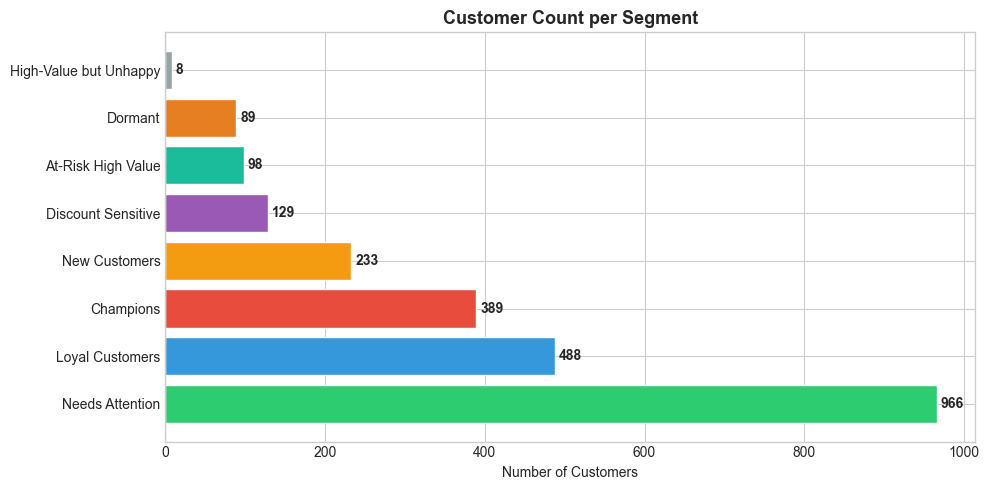

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
seg_counts = rfm['segment'].value_counts()
colors     = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c','#e67e22','#95a5a6']

bars = ax.barh(seg_counts.index, seg_counts.values,
               color=colors[:len(seg_counts)], edgecolor='white')
ax.set_title('Customer Count per Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
for bar, v in zip(bars, seg_counts.values):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/01_segment_size.png', dpi=150, bbox_inches='tight')
plt.show()

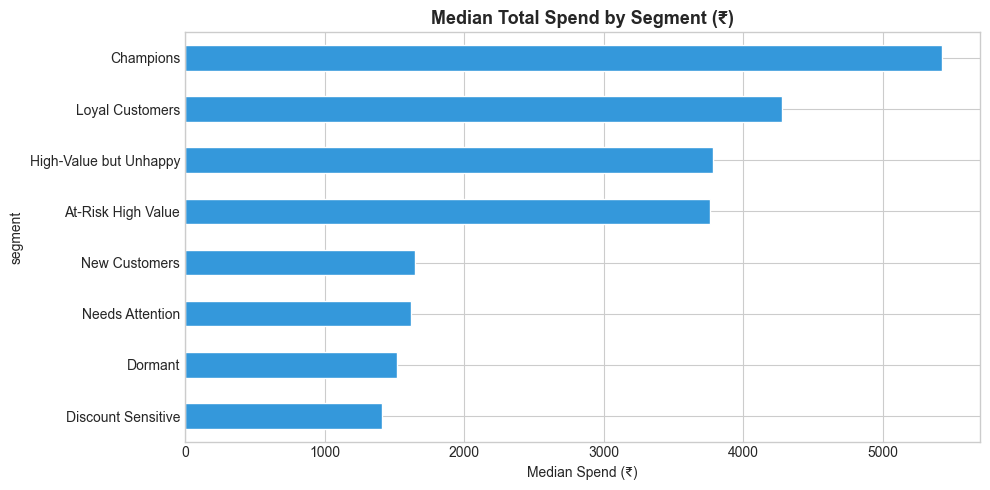

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
seg_spend = rfm.groupby('segment')['monetary'].median().sort_values(ascending=True)
seg_spend.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Median Total Spend by Segment (₹)', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Spend (₹)')
plt.tight_layout()
plt.savefig('charts/02_spend_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

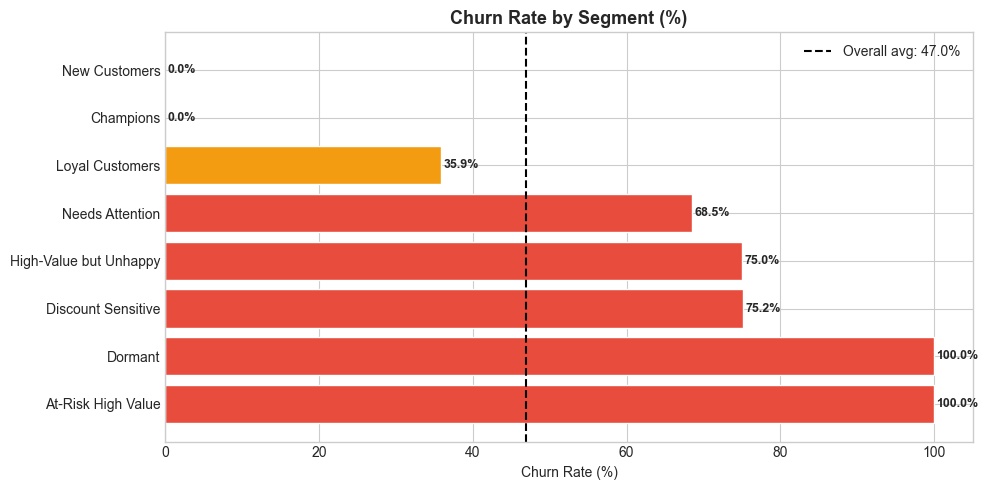

In [13]:
churn_by_seg = rfm.groupby('segment')['churned'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_churn = ['#e74c3c' if v > 0.4 else '#f39c12' if v > 0.2 else '#27ae60'
                for v in churn_by_seg.values]
bars = ax.barh(churn_by_seg.index, churn_by_seg.values * 100,
               color=colors_churn, edgecolor='white')
ax.axvline(rfm['churned'].mean() * 100, color='black', linestyle='--',
           linewidth=1.5, label=f'Overall avg: {rfm["churned"].mean()*100:.1f}%')
ax.set_title('Churn Rate by Segment (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
for bar, v in zip(bars, churn_by_seg.values):
    ax.text(v * 100 + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v*100:.1f}%', va='center', fontweight='bold', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('charts/03_churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

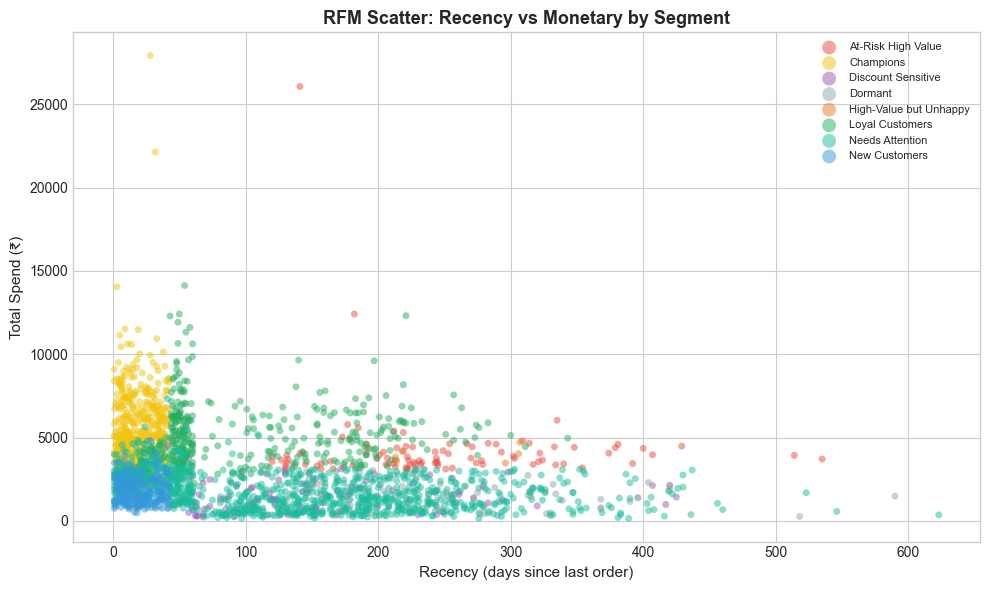

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
segment_colors = {
    'Champions':              '#f1c40f',
    'Loyal Customers':        '#27ae60',
    'At-Risk High Value':     '#e74c3c',
    'High-Value but Unhappy': '#e67e22',
    'New Customers':          '#3498db',
    'Dormant':                '#95a5a6',
    'Discount Sensitive':     '#9b59b6',
    'Needs Attention':        '#1abc9c'
}

for seg, grp in rfm.groupby('segment'):
    ax.scatter(grp['recency'], grp['monetary'],
               label=seg, c=segment_colors.get(seg, '#333'),
               alpha=0.5, s=25, edgecolors='none')

ax.set_xlabel('Recency (days since last order)', fontsize=11)
ax.set_ylabel('Total Spend (₹)', fontsize=11)
ax.set_title('RFM Scatter: Recency vs Monetary by Segment', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, markerscale=2)
plt.tight_layout()
plt.savefig('charts/04_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
summary = rfm.groupby('segment').agg(
    count         = ('customer_id',    'count'),
    avg_recency   = ('recency',        'mean'),
    avg_frequency = ('frequency',      'mean'),
    avg_monetary  = ('monetary',       'mean'),
    avg_tickets   = ('ticket_count',   'mean'),
    avg_sessions  = ('recent_sessions','mean'),
    churn_rate    = ('churned',        'mean')
).round(2).sort_values('churn_rate', ascending=False)

print("Segment Summary Table:")
print(summary.to_string())

Segment Summary Table:
                        count  avg_recency  avg_frequency  avg_monetary  avg_tickets  avg_sessions  churn_rate
segment                                                                                                       
At-Risk High Value         98       243.22           4.08       4209.17         0.89          3.56        1.00
Dormant                    89       246.99           2.29       1548.74         0.56          0.00        1.00
Discount Sensitive        129       131.52           2.19       1553.54         1.14          5.53        0.75
High-Value but Unhappy      8       201.12           4.75       3857.28         3.00          2.88        0.75
Needs Attention           966       143.29           2.53       1713.95         0.42          5.02        0.69
Loyal Customers           488        84.49           6.43       4678.02         1.30          6.01        0.36
Champions                 389        18.57           7.60       5938.23         1.34     

In [16]:
output_cols = [
    'customer_id', 'segment',
    'recency', 'frequency', 'monetary', 'avg_order_value',
    'R_score', 'F_score', 'M_score', 'RFM_score',
    'ticket_count', 'return_rate', 'recent_sessions'
]
rfm[output_cols].to_csv('segments.csv', index=False)
print(f"Saved segments.csv — {len(rfm):,} customers")
rfm[output_cols].head()

Saved segments.csv — 2,400 customers


,customer_id,segment,recency,frequency,monetary,avg_order_value,R_score,F_score,M_score,RFM_score,ticket_count,return_rate,recent_sessions
0,CUST00001,Needs Attention,168,6,2955.57,492.595000,2,4,3,9,2.0,0.166667,1
1,CUST00002,New Customers,35,3,1713.10,571.033333,4,2,2,8,1.0,0.000000,8
2,CUST00003,Needs Attention,232,1,649.98,649.980000,1,1,1,3,0.0,0.000000,1
3,CUST00004,Needs Attention,192,1,1604.04,1604.040000,2,1,2,5,0.0,0.000000,1
4,CUST00005,Champions,11,6,3910.43,651.738333,5,4,4,13,1.0,0.000000,18
